In [1]:
# packages
import os
import joblib
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.pyplot import subplots
import statsmodels.api as sm
from sklearn.model_selection import train_test_split 
from sklearn.ensemble import GradientBoostingRegressor as GBR
from sklearn.model_selection import GridSearchCV

# set seed
seed = 5151

### You'll need the California housing data (CAhousing.csv) to complete this exercise. Your goal is to predict the median house value.

In [3]:
CAhousing = pd.read_csv('data/CAhousing.csv')
CAhousing.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-120.45,34.66,7.0,3329.0,504.0,1462.0,452.0,4.7875,198300.0,NEAR OCEAN
1,-114.64,34.83,10.0,2502.0,573.0,1152.0,481.0,1.7062,86800.0,INLAND
2,-117.24,32.74,43.0,2216.0,375.0,918.0,388.0,5.5289,297700.0,NEAR OCEAN
3,-122.43,37.76,52.0,3771.0,1017.0,1575.0,921.0,3.5655,427300.0,NEAR BAY
4,-118.02,34.13,34.0,1966.0,319.0,980.0,297.0,7.7307,429000.0,INLAND


In [4]:
CAhousing.dtypes

longitude             float64
latitude              float64
housing_median_age    float64
total_rooms           float64
total_bedrooms        float64
population            float64
households            float64
median_income         float64
median_house_value    float64
ocean_proximity        object
dtype: object

In [5]:
CAhousing.shape

(15480, 10)

### There is a single categorical variable in this dataset that we will convert to a series of binary variables.

In [10]:
CAhousing['ocean_proximity'].value_counts()

ocean_proximity
<1H OCEAN     6857
INLAND        4933
NEAR OCEAN    1974
NEAR BAY      1712
ISLAND           4
Name: count, dtype: int64

In [12]:
# create binary variables for levels which have enough records, using '<1H OCEAN' as base.
CAhousing['ocean_prox_inland'] = (CAhousing.ocean_proximity == 'INLAND').astype(int)
CAhousing['ocean_prox_nearocean'] = (CAhousing.ocean_proximity == 'NEAR OCEAN').astype(int)
CAhousing['ocean_prox_nearbay'] = (CAhousing.ocean_proximity == 'NEAR BAY').astype(int)

# check for intended outcome
print(CAhousing['ocean_prox_inland'].value_counts())
print(CAhousing['ocean_prox_nearocean'].value_counts())
print(CAhousing['ocean_prox_nearbay'].value_counts())

ocean_prox_inland
0    10547
1     4933
Name: count, dtype: int64
ocean_prox_nearocean
0    13506
1     1974
Name: count, dtype: int64
ocean_prox_nearbay
0    13768
1     1712
Name: count, dtype: int64


In [16]:
indep_vars = ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 
              'total_bedrooms', 'population', 'households', 'median_income', 
              'ocean_prox_inland', 'ocean_prox_nearocean', 'ocean_prox_nearbay']

X = CAhousing[indep_vars]
y = CAhousing['median_house_value']

In [18]:
X_train, X_test, y_train, y_test, Train, Test = train_test_split(X, y, CAhousing, 
                                                                 random_state = seed, 
                                                                 test_size = 0.33, 
                                                                 shuffle = True)

In [20]:
X_train.corr().style.background_gradient(cmap='coolwarm', vmin=-1, vmax=1)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_prox_inland,ocean_prox_nearocean,ocean_prox_nearbay
longitude,1.000000,-0.924779,-0.118552,0.044445,0.067878,0.095517,0.056249,-0.001915,-0.068406,0.047632,-0.471177
latitude,-0.924779,1.000000,0.017276,-0.034301,-0.064393,-0.104774,-0.070660,-0.091395,0.362431,-0.162865,0.352288
housing_median_age,-0.118552,0.017276,1.000000,-0.356225,-0.312179,-0.296755,-0.297747,-0.127980,-0.234810,0.019505,0.266093
total_rooms,0.044445,-0.034301,-0.356225,1.000000,0.929524,0.863705,0.920233,0.194707,0.017204,-0.002551,-0.027185
total_bedrooms,0.067878,-0.064393,-0.312179,0.929524,1.000000,0.884256,0.982181,-0.012983,-0.014767,0.006178,-0.023290
population,0.095517,-0.104774,-0.296755,0.863705,0.884256,1.000000,0.910754,0.003736,-0.028679,-0.014128,-0.065967
households,0.056249,-0.070660,-0.297747,0.920233,0.982181,0.910754,1.000000,0.009063,-0.044852,0.007238,-0.015839
median_income,-0.001915,-0.091395,-0.127980,0.194707,-0.012983,0.003736,0.009063,1.000000,-0.237863,0.026168,0.057597
ocean_prox_inland,-0.068406,0.362431,-0.234810,0.017204,-0.014767,-0.028679,-0.044852,-0.237863,1.000000,-0.261267,-0.242334
ocean_prox_nearocean,0.047632,-0.162865,0.019505,-0.002551,0.006178,-0.014128,0.007238,0.026168,-0.261267,1.000000,-0.132228


In [22]:
Train.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_prox_inland,ocean_prox_nearocean,ocean_prox_nearbay
count,10371.000000,10371.000000,10371.000000,10371.000000,10257.000000,10371.000000,10371.000000,10371.000000,10371.000000,10371.000000,10371.000000,10371.000000
mean,-119.576317,35.648347,28.707646,2631.445569,537.541484,1426.518851,500.422524,3.868065,206399.612284,0.323787,0.124771,0.109247
std,1.997211,2.140070,12.631120,2173.616930,425.582759,1137.463225,388.555637,1.885826,115215.425942,0.467943,0.330475,0.311964
min,-124.260000,32.560000,1.000000,8.000000,1.000000,5.000000,1.000000,0.499900,14999.000000,0.000000,0.000000,0.000000
25%,-121.770000,33.940000,18.000000,1454.000000,296.000000,791.000000,282.000000,2.556800,118750.000000,0.000000,0.000000,0.000000
50%,-118.510000,34.260000,29.000000,2126.000000,435.000000,1163.000000,410.000000,3.534500,179800.000000,0.000000,0.000000,0.000000
75%,-118.020000,37.730000,37.000000,3127.000000,640.000000,1719.000000,601.000000,4.747400,264000.000000,1.000000,0.000000,0.000000
max,-114.310000,41.950000,52.000000,37937.000000,6445.000000,28566.000000,6082.000000,15.000100,500001.000000,1.000000,1.000000,1.000000


### We see that `total_bedrooms` has a few missing values, and it is also very correlated with `total_rooms`. Because of this, it's easiest to remove it from our training set.

In [25]:
indep_vars.remove("total_bedrooms")

### We'll define some helper functions here: 
(1) to calculate MSE, and 
(2) to display the improvement of a GBM on test data as additional trees are constructed.

In [28]:
def mse(y, y_hat):
    """
    Calculate the MSE of a model given actual and predicted values
    """
    # calculate the residual error for each individual record
    resid = y - y_hat
    # square the residual (hence "squared error")
    sq_resid = resid**2
    # calculate the sum of squared errors
    SSR = sum(sq_resid)
    # divide by the number of records to get the mean squared error
    MSE = SSR / y.shape[0]
    return MSE

def gbm_progress(model_name, X_test, y_test):
    """
    Plot the 'progress' of a GBM on a test set to assess robustness
    """
    test_error = np.zeros_like(model_name.train_score_)
    for idx, y_ in enumerate(model_name.staged_predict(X_test)):
        test_error[idx] = np.mean((y_test - y_)**2)

    plot_idx = np.arange(model_name.train_score_.shape[0])
    ax = subplots(figsize=(8,8))[1]
    ax.plot(plot_idx,
            model_name.train_score_,
            'b',
            label='Training')
    ax.plot(plot_idx,
            test_error,
            'r',
            label='Test')
    ax.legend();

### Build a basic GBM first.

In [31]:
# Documentation: https://scikit-learn.org/dev/modules/generated/sklearn.ensemble.GradientBoostingRegressor.html

gbm_basic = GBR(learning_rate=0.1,
               n_estimators=250,
               max_depth=10,
               min_samples_split=2,
               subsample=1,
               random_state=seed)

gbm_basic.fit(X_train[indep_vars], y_train)

GradientBoostingRegressor(max_depth=10, n_estimators=250, random_state=5151,
                          subsample=1)

In [32]:
y_hat_basic = gbm_basic.predict(X_test[indep_vars])

mse_basic = mse(y_test, y_hat_basic)
print('test mse: ',mse_basic)

test mse:  2524578849.5044518


### When we plot the performance of the model on training and test data, we see that performance no longer improves after a certain number of trees (in this case, between 50-100 trees).

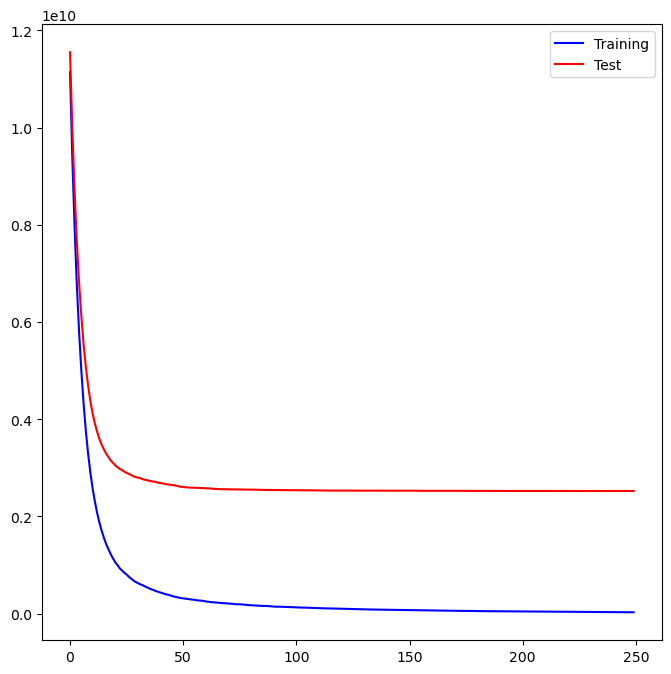

In [34]:
gbm_progress(gbm_basic, X_test[indep_vars], y_test)

### Now you'll have the chance to choose optimal hyperparameters to build a better GBM.
Once the candidate hyperparameters are chosen, use 5-fold cross-validation to decide which collection of hyperparameters are best.

In [ ]:
def get_best_gbm(X, y, results_path="gridsearch_results.pkl", force_retrain=False):
    """
    Runs GridSearchCV OR loads precomputed results if available.

    Parameters:
        X, y : training data
        results_path : where results are saved
        force_retrain : if True, ignore saved file and rerun

    Returns:
        best_model : fitted model
        best_params : dict
    """

    # Fast Version: load existing results
    if os.path.exists(results_path) and not force_retrain:
        data = joblib.load(results_path)
        print("Loaded precomputed GridSearchCV results.")
        return data["best_model"], data["best_params"]

    # Slow Version: run grid search via cross-validation
    print("Running GridSearchCV...")

    ## Define model
    gbm_cv = GBR(random_state=seed)

    ## Define hyperparameter grid. Choose between 1 and 4 values to test for each one.
    #fillin
    param_grid = {
        "n_estimators":[6000],
        "learning_rate": [0.01],
        "max_depth": [6],
        "min_samples_leaf": [5],
        "subsample": [0.8]
    }

    grid_search = GridSearchCV(
        estimator=gbm_cv,
        param_grid=param_grid,
        cv=5,                               # number of folds
        scoring="neg_mean_squared_error",   # how we evaluate which model is best
        n_jobs=-1,                          # use all available cores
        verbose=3
    )

    grid_search.fit(X, y)

    best_model = grid_search.best_estimator_
    best_params = grid_search.best_params_

    ## Save results. Gradescope will use this file instead of rerunning the grid search.
    joblib.dump({
        "best_model": best_model,
        "best_params": best_params,
        "cv_results": grid_search.cv_results_
    }, results_path)

    print(f"Saved results to {results_path}")

    return best_model, best_params

In [ ]:
# Identify best model
best_model, best_params = get_best_gbm(X_train[indep_vars], y_train, force_retrain=False)

print("Best parameters:")
print(best_params)

Running GridSearchCV...
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Saved results to gridsearch_results.pkl
Best parameters:
{'learning_rate': 0.01, 'max_depth': 6, 'min_samples_leaf': 5, 'n_estimators': 6000, 'subsample': 0.8}


### Your grade on this assignment will be partially determined by the mean squared error on a separate holdout set. You can approximate this using the test set.

In [ ]:
# Evaluate on test set 
y_pred = best_model.predict(X_test[indep_vars])
mse_best = mse(y_test, y_pred)

print("Test MSE:", mse_best)

Test MSE: 2127039167.0944052
